# **HANDS - ON: HERRAMIENTAS DE ANÁLISIS DE DATOS**

Una vez visto la presentación ***Herramientas de análisis de datos***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1e42MuBMd3N-T6csFeKFArZzYOQWoarmV?usp=sharing).

## **INTRODUCCIÓN A PANDAS**

**Pandas** es una biblioteca fundamental en Python para la **manipulación y análisis de datos**, nacida como una evolución de NumPy. Proporciona estructuras de datos flexibles y eficientes, como DataFrames y Series, que facilitan la importación, limpieza, transformación, agregación y visualización de datos. Con Pandas, puedes realizar operaciones complejas sobre datos tabulares y series temporales de manera intuitiva, lo que lo convierte en una herramienta indispensable para científicos de datos, analistas y cualquier persona que trabaje con grandes volúmenes de información.

En dado caso de no tener instalado Numpy, se debe usar [pip](https://pip.pypa.io/en/stable/) que es el instalador de paquetes para Python.

```
! pip install pandas
```

In [2]:
# Importar librerías
import numpy as np
import pandas as pd

### **SERIES**

Una **Serie** de Pandas, es un objeto similar a un vector, que contiene una secuencia de valores y un vector asociado de etiquetas llamado indice.

Basicamente, una serie es una columna de un DataFrame.

De manera similar a los arrays de Numpy, podemos crear una serie pasandole una lista a su constructor.

In [3]:
# Crear array vector con 4 elementos secuenciales del 1 al 4
array = np.arange(1,5)
array

array([1, 2, 3, 4])

In [4]:
# Crear una serie de números con los elementos del 1 al 4
serie = pd.Series(array)
serie

0    1
1    2
2    3
3    4
dtype: int64

Adicional a las funciones de creacion de datos de Numpy, Pandas tambien tiene funcionalidad de creacion de datos, por ejemplo podemos hacer un indice con un rango de datos usando `pd.date_range`.

In [5]:
# Crear DatetimeIndex con fecha de inicio del año 2024 con 4 periodos de frecuencia por mes
fecha = pd.date_range(start='2024-01-01', periods=4, freq='MS')
fecha

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01'], dtype='datetime64[ns]', freq='MS')

A diferencia de los Numpy arrays, los indices son arbitrarios y nos permite acceder relacionar la informacion con algun dato de interes. Ademas nos permite seleccionar la informacion por medio del uso de estos indices.

In [6]:
# Crear serie con los elementos del array vector y con los indices de la serie de fechas
serie = pd.Series(array, index=fecha)
serie

2024-01-01    1
2024-02-01    2
2024-03-01    3
2024-04-01    4
Freq: MS, dtype: int64

In [7]:
# Renombrar columna por la letra A
serie = serie.rename('A')
serie

2024-01-01    1
2024-02-01    2
2024-03-01    3
2024-04-01    4
Freq: MS, Name: A, dtype: int64

#### **INDEXACIÓN**

La **indexación** en Pandas, similar a NumPy y listas de Python, permite acceder a elementos por posición. Sin embargo, Pandas destaca por sus índices explícitos que van mas allá de la numérica, posibilitando la selección basada en etiquetas además de la posición.

In [8]:
# Indexar serie por indice de fecha
serie['2024-01-01']

np.int64(1)

In [9]:
# Indexar serie por indices de fechas salteadas
serie[['2024-01-01', '2024-03-01']]

2024-01-01    1
2024-03-01    3
Name: A, dtype: int64

In [10]:
# Indexar serie por condición booleana
serie[serie > 2]

2024-03-01    3
2024-04-01    4
Freq: MS, Name: A, dtype: int64

In [11]:
# Indexar serie por rango de indices
serie['2024-01-01':'2024-03-01']

2024-01-01    1
2024-02-01    2
2024-03-01    3
Freq: MS, Name: A, dtype: int64

### **DATAFRAMES**

Un **DataFrame** de Pandas representa una tabla rectangular de datos y contiene una colección ordenada de columnas, cada una de las cuales puede ser un tipo de valor diferente (numérico, string, booleano, etc).

Los DataFrames tienen un índice de fila y columna; se puede pensar en
como un diccionario de **Series**, las cuales comparten el mismo índice.

Una manera de crear un DataFrames es a partir de las Series ya creadas en Python.

In [12]:
# Crear dataframe haciendo uso de un diccionario
df = pd.DataFrame({
    "A": 1.0,
    "B": np.arange(1, 21),
    "C": np.zeros(20),
    "D": np.ones(20),
    "E": np.random.random(20),
    "F": np.random.randint(0, 20, size = 20),
    "G": "DEV.F"
})

df

,A,B,C,D,E,F,G
0,1.0,1,0.0,1.0,0.438253,19,DEV.F
1,1.0,2,0.0,1.0,0.730028,15,DEV.F
2,1.0,3,0.0,1.0,0.598694,13,DEV.F
3,1.0,4,0.0,1.0,0.588064,10,DEV.F
4,1.0,5,0.0,1.0,0.797549,7,DEV.F
5,1.0,6,0.0,1.0,0.136305,9,DEV.F
6,1.0,7,0.0,1.0,0.832994,17,DEV.F
7,1.0,8,0.0,1.0,0.760260,16,DEV.F
8,1.0,9,0.0,1.0,0.782358,11,DEV.F
9,1.0,10,0.0,1.0,0.332256,11,DEV.F


In [13]:
# Cambiar los indices de la filas del dataframe por una serie de fecha
df.index = pd.date_range(start='2024-01-01', periods=20, freq='D')
df

,A,B,C,D,E,F,G
2024-01-01,1.0,1,0.0,1.0,0.438253,19,DEV.F
2024-01-02,1.0,2,0.0,1.0,0.730028,15,DEV.F
2024-01-03,1.0,3,0.0,1.0,0.598694,13,DEV.F
2024-01-04,1.0,4,0.0,1.0,0.588064,10,DEV.F
2024-01-05,1.0,5,0.0,1.0,0.797549,7,DEV.F
2024-01-06,1.0,6,0.0,1.0,0.136305,9,DEV.F
2024-01-07,1.0,7,0.0,1.0,0.832994,17,DEV.F
2024-01-08,1.0,8,0.0,1.0,0.760260,16,DEV.F
2024-01-09,1.0,9,0.0,1.0,0.782358,11,DEV.F
2024-01-10,1.0,10,0.0,1.0,0.332256,11,DEV.F


El atributo `dtypes` nos permite conocer el tipo de datos de cada columna de un DataFrame

In [14]:
# Observar los tipos de datos de cada columna del dataframe
df.dtypes

A    float64
B      int64
C    float64
D    float64
E    float64
F      int32
G     object
dtype: object

Para extrae el indice de la tabla se utiliza `.index`  

In [15]:
# Extraer los indices del dataFrame
df.index

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-12',
               '2024-01-13', '2024-01-14', '2024-01-15', '2024-01-16',
               '2024-01-17', '2024-01-18', '2024-01-19', '2024-01-20'],
              dtype='datetime64[ns]', freq='D')

Para extraer las columnas de la tabla se utiliza `.columns`  

In [16]:
# Extraer las columnas del dataFrame
df.columns

Index(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype='object')

#### **INDEXACIÓN**

Los **DataFrames** comparten el mismo índice que las Series. Esto permite una indexación potente y flexible, similar a las Series, pero en dos dimensiones (filas y columnas).

In [17]:
# Indexar dataframe por variable e indice
df['E']['2024-01-13']

np.float64(0.5752799138742462)

In [18]:
# Indexar dataframe por condición booleana en la variable
df["E"] > 0.5

2024-01-01    False
2024-01-02     True
2024-01-03     True
2024-01-04     True
2024-01-05     True
2024-01-06    False
2024-01-07     True
2024-01-08     True
2024-01-09     True
2024-01-10    False
2024-01-11    False
2024-01-12    False
2024-01-13     True
2024-01-14     True
2024-01-15    False
2024-01-16    False
2024-01-17     True
2024-01-18    False
2024-01-19    False
2024-01-20    False
Freq: D, Name: E, dtype: bool

In [19]:
# Indexar dataframe por indices y variables conjuntas
df['2024-01-08': '2024-01-16'][['C', 'D', 'E']]

,C,D,E
2024-01-08,0.0,1.0,0.760260
2024-01-09,0.0,1.0,0.782358
2024-01-10,0.0,1.0,0.332256
2024-01-11,0.0,1.0,0.338614
2024-01-12,0.0,1.0,0.158044
2024-01-13,0.0,1.0,0.575280
2024-01-14,0.0,1.0,0.696070
2024-01-15,0.0,1.0,0.204741
2024-01-16,0.0,1.0,0.334021


In [20]:
# Indexar dataframe por indices y variables salteadas
df['2024-01-08': '2024-01-16'][['B', 'E', 'G']]

,B,E,G
2024-01-08,8,0.760260,DEV.F
2024-01-09,9,0.782358,DEV.F
2024-01-10,10,0.332256,DEV.F
2024-01-11,11,0.338614,DEV.F
2024-01-12,12,0.158044,DEV.F
2024-01-13,13,0.575280,DEV.F
2024-01-14,14,0.696070,DEV.F
2024-01-15,15,0.204741,DEV.F
2024-01-16,16,0.334021,DEV.F


##### **INDEXACIÓN POR MÉTODOS EXPECIALES**


En Pandas, `.loc` e `.iloc` son **métodos fundamentales para acceder a datos** dentro de un DataFrame.

*   `.loc` se basa en etiquetas, lo que te permite seleccionar filas y columnas por sus nombres o una condición booleana.


*   `.iloc` utiliza índices numéricos, proporcionando acceso a los datos según su posición entera en el DataFrame.

**Ambos métodos son esenciales para filtrar, seleccionar y manipular datos de manera eficiente** en Pandas, aunque la elección entre ellos depende de prefirir usar etiquetas o posiciones numéricas para identificar los elementos de interes.

###### **MÉTODO POR ETIQUETA**

In [21]:
# Indexar dataframe por indices y variables salteadas
df.loc[['2024-01-06', '2024-01-13', '2024-01-19'], ['B', 'E', 'G']]

,B,E,G
2024-01-06,6,0.136305,DEV.F
2024-01-13,13,0.575280,DEV.F
2024-01-19,19,0.129498,DEV.F


In [22]:
# Mostrar el elemento desde el indice 6 la variable 'D' del dataframe
df.loc['2024-01-06', 'D']

np.float64(1.0)

In [23]:
# Indexar dataframe por condición booleana en la variable
df.loc[df['E'] > 0.5]

,A,B,C,D,E,F,G
2024-01-02,1.0,2,0.0,1.0,0.730028,15,DEV.F
2024-01-03,1.0,3,0.0,1.0,0.598694,13,DEV.F
2024-01-04,1.0,4,0.0,1.0,0.588064,10,DEV.F
2024-01-05,1.0,5,0.0,1.0,0.797549,7,DEV.F
2024-01-07,1.0,7,0.0,1.0,0.832994,17,DEV.F
2024-01-08,1.0,8,0.0,1.0,0.760260,16,DEV.F
2024-01-09,1.0,9,0.0,1.0,0.782358,11,DEV.F
2024-01-13,1.0,13,0.0,1.0,0.575280,13,DEV.F
2024-01-14,1.0,14,0.0,1.0,0.696070,19,DEV.F
2024-01-17,1.0,17,0.0,1.0,0.710670,16,DEV.F


###### **MÉTODO POR POSICIÓN**

In [24]:
# Indexar dataframe por indices y variables salteadas
df.iloc[[5, 12, 18], [1, 4, 6]]

,B,E,G
2024-01-06,6,0.136305,DEV.F
2024-01-13,13,0.575280,DEV.F
2024-01-19,19,0.129498,DEV.F


In [25]:
# Mostrar el elemento desde el indice 12 de la variable 4 del dataframe
df.iloc[12, 4]

np.float64(0.5752799138742462)

In [26]:
# Indexar por rangos de indice desde la fila 1 hasta el 8 del dataframe
df.iloc[1:8]

,A,B,C,D,E,F,G
2024-01-02,1.0,2,0.0,1.0,0.730028,15,DEV.F
2024-01-03,1.0,3,0.0,1.0,0.598694,13,DEV.F
2024-01-04,1.0,4,0.0,1.0,0.588064,10,DEV.F
2024-01-05,1.0,5,0.0,1.0,0.797549,7,DEV.F
2024-01-06,1.0,6,0.0,1.0,0.136305,9,DEV.F
2024-01-07,1.0,7,0.0,1.0,0.832994,17,DEV.F
2024-01-08,1.0,8,0.0,1.0,0.760260,16,DEV.F


In [27]:
# Indexar por rangos de variables desde la variable 3 hasta la penúltima variable del dataframe
df.iloc[:, 2:-1]

,C,D,E,F
2024-01-01,0.0,1.0,0.438253,19
2024-01-02,0.0,1.0,0.730028,15
2024-01-03,0.0,1.0,0.598694,13
2024-01-04,0.0,1.0,0.588064,10
2024-01-05,0.0,1.0,0.797549,7
2024-01-06,0.0,1.0,0.136305,9
2024-01-07,0.0,1.0,0.832994,17
2024-01-08,0.0,1.0,0.760260,16
2024-01-09,0.0,1.0,0.782358,11
2024-01-10,0.0,1.0,0.332256,11


#### **SELECCIÓN**


En Pandas, los métodos `.head()` y `.tail()` son **herramientas prácticas para obtener una vista previa** rápida de un DataFrame.

*   `.head()` devuelve las primeras filas de un DataFrame.
*   `.tail()` devuelve las últimas filas de un DataFrame.

Ambos métodos aceptan un argumento opcional que especifica el número de filas a mostrar (por defecto, 5). **Son especialmente útiles cuando se trabaja con grandes conjuntos de datos**, ya que permiten inspeccionar los datos sin tener que cargar todo el DataFrame en la memoria.

In [28]:
# Mostrar los primeros 5 elementos del dataframe
df.head()

,A,B,C,D,E,F,G
2024-01-01,1.0,1,0.0,1.0,0.438253,19,DEV.F
2024-01-02,1.0,2,0.0,1.0,0.730028,15,DEV.F
2024-01-03,1.0,3,0.0,1.0,0.598694,13,DEV.F
2024-01-04,1.0,4,0.0,1.0,0.588064,10,DEV.F
2024-01-05,1.0,5,0.0,1.0,0.797549,7,DEV.F


In [29]:
# Mostrar los ultimos 5 elementos del dataframe
df.tail()

,A,B,C,D,E,F,G
2024-01-16,1.0,16,0.0,1.0,0.334021,7,DEV.F
2024-01-17,1.0,17,0.0,1.0,0.710670,16,DEV.F
2024-01-18,1.0,18,0.0,1.0,0.380251,9,DEV.F
2024-01-19,1.0,19,0.0,1.0,0.129498,5,DEV.F
2024-01-20,1.0,20,0.0,1.0,0.129359,3,DEV.F


## **INTRODUCCIÓN A SEABORN**

**Seaborn** es una biblioteca de Python para la **creación de gráficos estadísticos**. Se basa en Matplotlib y se integra fluidamente con las estructuras de datos de Pandas. Esta herramienta destaca por simplificar la creación de visualizaciones de datos atractivas e informativas. Además, cuenta con estilos y paletas de colores predefinidos que mejoran la estética de los gráficos.

En dado caso de no tener instalado Numpy, se debe usar [pip](https://pip.pypa.io/en/stable/) que es el instalador de paquetes para Python.

```
! pip install seaborn
```

In [30]:
# Importar librerías
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
# Cargar dataset
df_tips = sns.load_dataset('tips')
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### **TIPOS DE GRÁFICOS**

Seaborn ofrece una variedad de tipos de gráficos para visualizar datos. Muchos de ellos muestran el **análisis de comportamientos de una o dos variables**.

#### **GRÁFICO DE DISPERSIÓN**

Un gráfico de dispersión se utiliza para visualizar la relación o correlación entre dos variables numéricas continuas. Cada punto en el gráfico representa una observación individual, con su posición determinada por los valores de las dos variables (una en el eje X y la otra en el eje Y).

<Axes: xlabel='total_bill', ylabel='tip'>

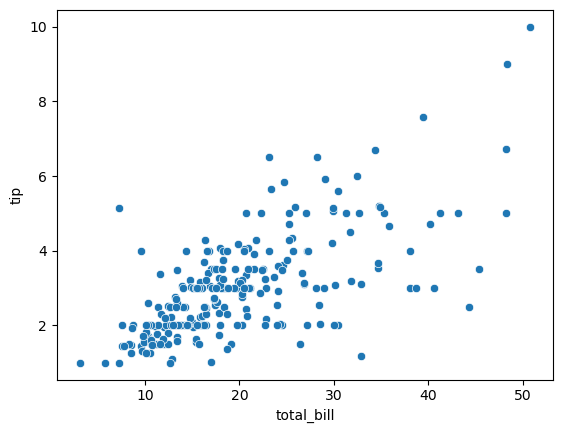

In [32]:
# Gráfico de dispersión que muestra la relación entre la cuenta total y la propina
sns.scatterplot(x = 'total_bill', y = 'tip', data = df_tips)

#### **HISTOGRAMA**

Un histograma es una representación gráfica de la distribución de una única variable numérica. Divide el rango de valores de la variable en una serie de intervalos o "bins" (generalmente de igual tamaño) y luego cuenta cuántas observaciones caen en cada intervalo. La altura de cada barra en el histograma es proporcional a la frecuencia (o densidad) de observaciones en ese intervalo.

<Axes: xlabel='total_bill', ylabel='Count'>

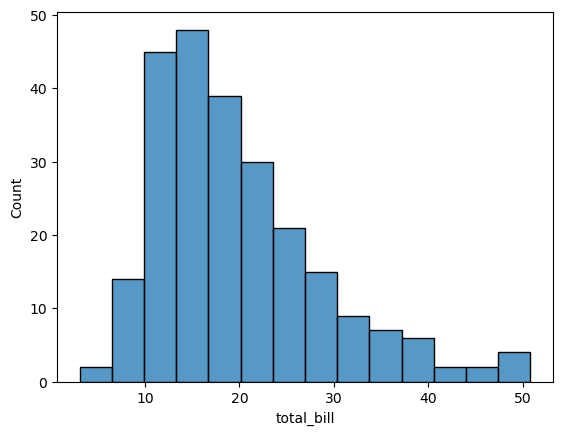

In [33]:
# Histograma que muestra la distribución de la cuenta total
sns.histplot(x='total_bill', data=df_tips)

#### **GRÁFICO DE BARRAS**

Los gráficos de barras se utilizan para comparar una métrica numérica (como una media, suma o conteo) entre diferentes categorías de una variable cualitativa o discreta. Cada barra representa una categoría, y la altura (o longitud) de la barra corresponde al valor de la métrica numérica para esa categoría. Seaborn, por defecto, suele mostrar la media de la variable numérica para cada categoría, junto con un intervalo de confianza.

<Axes: xlabel='day', ylabel='tip'>

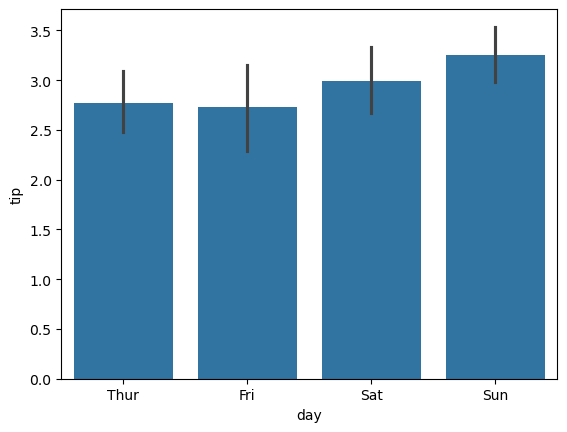

In [34]:
# Gráfico de barras que muestra la propina promedio por día de la semana
sns.barplot(x='day', y='tip', data=df_tips)

#### **GRÁFICO DE CAJA**

Un gráfico de caja, también conocido como diagrama de caja y bigotes, es una forma estandarizada de mostrar la distribución de datos numéricos basada en cinco números resumen: el mínimo, el primer cuartil (Q1, percentil 25), la mediana (Q2, percentil 50), el tercer cuartil (Q3, percentil 75) y el máximo. La "caja" representa el rango intercuartílico (IQR = Q3 - Q1), que contiene el 50% central de los datos. Los "bigotes" se extienden desde la caja para mostrar el resto de la distribución, típicamente hasta 1.5 veces el IQR. Los puntos más allá de los bigotes se consideran valores atípicos.

<Axes: xlabel='time', ylabel='total_bill'>

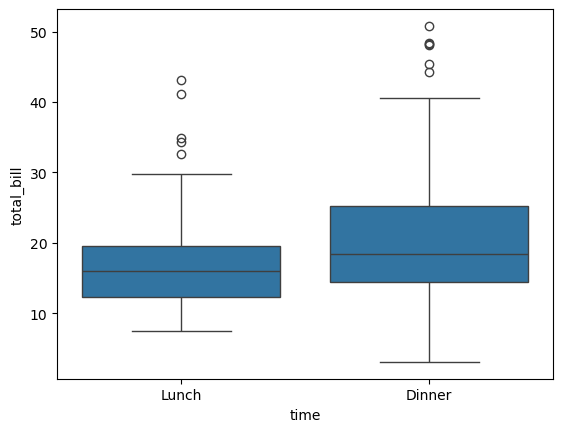

In [35]:
# Gráfico de caja que muestra la distribución de la cuenta total por hora del día
sns.boxplot(x='time', y='total_bill', data=df_tips)

#### **GRÁFICO DE VIOLÍN**

Un gráfico de violín es una combinación de un gráfico de caja y un gráfico de densidad (Kernel Density Estimate o KDE) rotado y colocado a cada lado para mostrar la forma de la distribución de los datos. La parte central del "violín" puede mostrar un mini gráfico de caja o simplemente la mediana y los cuartiles. El ancho del violín en un punto particular representa la densidad de los datos en ese valor.

<Axes: xlabel='sex', ylabel='tip'>

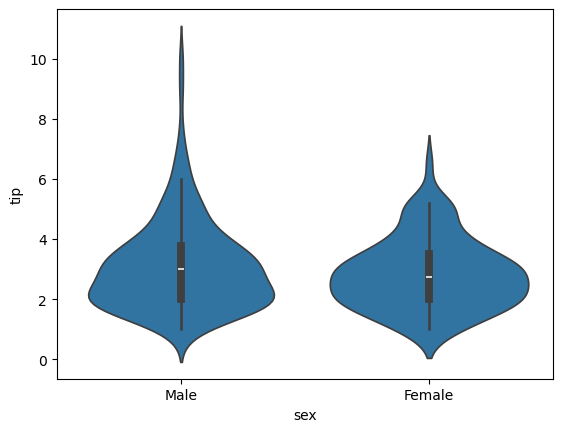

In [36]:
# Gráfico de violín que muestra la distribución de la propina por sexo
sns.violinplot(x='sex', y='tip', data=df_tips)

#### **MAPA DE CALOR**

Un mapa de calor es una representación gráfica de datos donde los valores individuales contenidos en una matriz se representan como colores.1 Generalmente, se utiliza una escala de colores para indicar la magnitud de los valores; por ejemplo, colores más oscuros o más intensos pueden representar valores más altos, y colores más claros, valores más bajos (o viceversa). Las filas y columnas de la matriz suelen representar diferentes variables o categorías.

In [37]:
# Convierte las columnas 'sexo' y 'fumador' a representaciones numéricas
df_tips['sex_codificado'] = pd.factorize(df_tips['sex'])[0]
df_tips['smoker_codificado'] = pd.factorize(df_tips['smoker'])[0]
df_tips['day_codificado'] = pd.factorize(df_tips['day'])[0]
df_tips['time_codificado'] = pd.factorize(df_tips['time'])[0]

<Axes: >

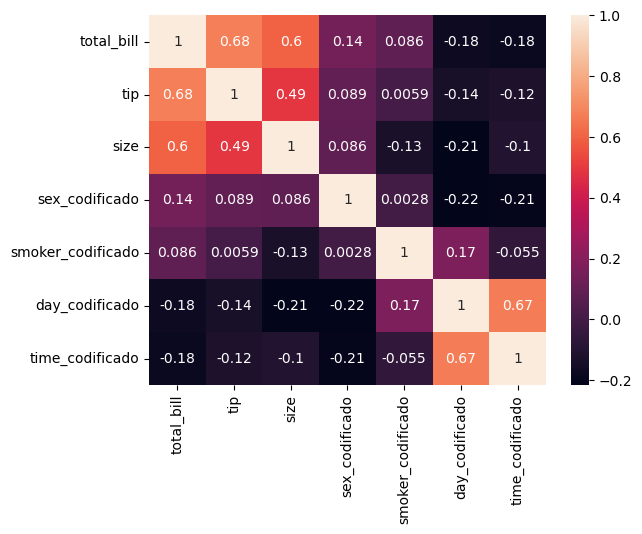

In [38]:
# Mapa de calor que muestra la correlación entre las variables numéricas del dataset

caracteristicas = ['total_bill', 'tip', 'size', 'sex_codificado', 'smoker_codificado', 'day_codificado', 'time_codificado']
sns.heatmap(df_tips[caracteristicas].corr(), annot = True)

### **PERSONALIZACIÓN DE GRÁFICOS**

Seaborn se basa en Matplotlib, lo que te permite personalizar aún más tus gráficos. Puedes usar las funciones de Matplotlib para agregar títulos, etiquetas, leyendas, cambiar colores, tamaños de fuente y mucho más.

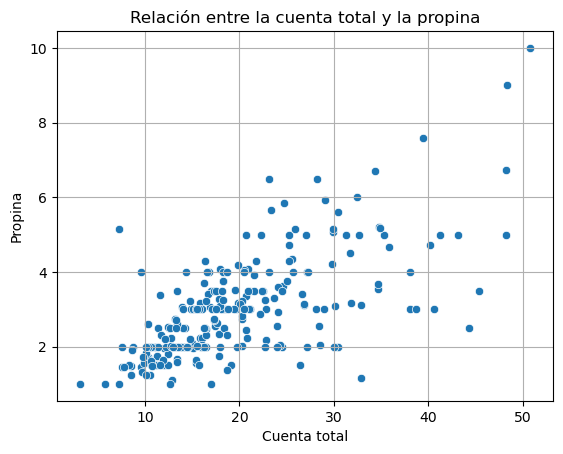

In [39]:
# Crear un gráfico de dispersión y personalizalo con Matplotlib
sns.scatterplot(x='total_bill', y='tip', data=df_tips)
plt.title('Relación entre la cuenta total y la propina')
plt.xlabel('Cuenta total')
plt.ylabel('Propina')
plt.grid()

(0.0, 60.0)

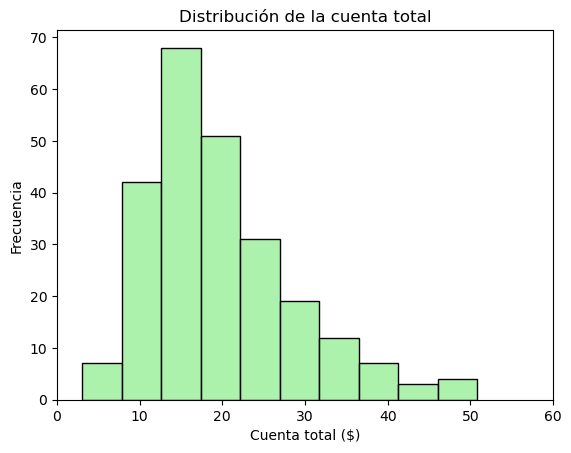

In [40]:
# Crear un histograma con Seaborn y personalizalo con Matplotlib
sns.histplot(x = 'total_bill', data = df_tips, bins = 10, color = 'lightgreen')
plt.title('Distribución de la cuenta total')
plt.xlabel('Cuenta total ($)')
plt.ylabel('Frecuencia')
plt.xlim(0, 60)

## **CHALLENGE: ANÁLISIS DE RENTABILIDAD SEMANAL**

Una vez visto el ***Hands - On: Herramientas de análisis de datos***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis profundo sobre el flujo de ingresos** de un restaurante para determinar la eficiencia de las propinas en relación con el día de la semana. Se hará uso de **herramientas de manipulación de datos, operaciones vectorizdas y análisis de datos** a través del dataset **"tips"**.

Donde los análisis a realizar son:

* **Consolidación de datos por categorías temporales**.
* **Relación entre el consumo total y gratificaciones**.
* **Identificación de patrones de comportamiento por género y día**.

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Pandas, Seaborn y Matplotlib.pyplot.










In [41]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**2. Carga de datos y visualización de estructura**

* Carga el dataset *tips*.
* Visualiza los tipos de datos de las columnas.

In [42]:
# Carga del dataset
df_tips = sns.load_dataset('tips')
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [51]:
df_tips.describe(include='all')

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
count,244.000000,244.000000,244,244,244,244,244.000000,244.000000
unique,NaN,NaN,2,2,4,2,NaN,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN,NaN
freq,NaN,NaN,157,151,87,176,NaN,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672,16.080258
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100,6.107220
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000,3.563814
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000,12.912736
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000,15.476977
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000,19.147549


In [44]:
# Ver tipos de datos
df_tips.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

**3. Creación de métrica: Porcentaje de Propina**

* Crea una nueva columna llamada tip_percentage.
* Calcular el porcentaje entre la propina y el total de la cuenta.
* Visualiza los primeros 10 registros.

In [45]:
# Creación de columna calculada
df_tips['tip_percentage'] = (df_tips['tip'] / df_tips['total_bill']) * 100
df_tips.head(10)

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
5,25.29,4.71,Male,No,Sun,Dinner,4,18.623962
6,8.77,2.00,Male,No,Sun,Dinner,2,22.805017
7,26.88,3.12,Male,No,Sun,Dinner,4,11.607143
8,15.04,1.96,Male,No,Sun,Dinner,2,13.031915
9,14.78,3.23,Male,No,Sun,Dinner,2,21.853857


**4. Filtrado Condicional: Comparativa por Género**

* Genera un nuevo dataframe para clientes hombres
* Genera un nuevo dataframe para clientes mujeres
* Compara los resumenes estadísticos de las propinas de los nuevos dataframes.

In [46]:
# Generar dataframes
hombres = df_tips[df_tips['sex'] == 'Male']
mujeres = df_tips[df_tips['sex'] == 'Female']

In [47]:
# Resumen estadístico de clientes hombres
hombres['tip'].describe()

count    157.000000
mean       3.089618
std        1.489102
min        1.000000
25%        2.000000
50%        3.000000
75%        3.760000
max       10.000000
Name: tip, dtype: float64

In [48]:
# Resumen estadístico de clientes mujeres
mujeres['tip'].describe()

count    87.000000
mean      2.833448
std       1.159495
min       1.000000
25%       2.000000
50%       2.750000
75%       3.500000
max       6.500000
Name: tip, dtype: float64

**5. Análisis Visual: ¿Cuánto gastan los fumadores?**

* Utiliza un gráfico de dispersión para ver la relación entre la cuenta total y la propina.

* Utiliza el parámetro `hue` para diferenciar a los clientes que son fumadores de los que no.

* Personaliza las dimensiones y los colores del gráfico para una mejor visualización con `style`.

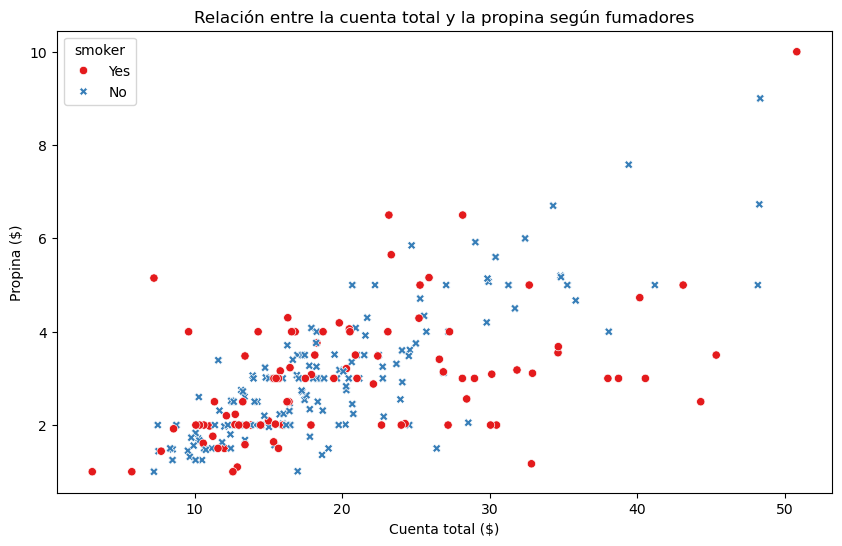

In [49]:
# Gráfico de dispersión: relación entre cuenta total y propina diferenciando fumadores
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_bill', y='tip', hue='smoker', style='smoker', data=df_tips, palette='Set1')
plt.title('Relación entre la cuenta total y la propina según fumadores')
plt.xlabel('Cuenta total ($)')
plt.ylabel('Propina ($)')
plt.show()

**6. Análisis de Frecuencia: Días de mayor afluencia**

* Utiliza un gráfico de conteo para visualizar qué días de la semana el restaurante recibe más mesas.  

* Utiliza el parámetro `hue` para diferenciar a los días conforme al conteo de mensas que son fumadores de los que no.

* Personaliza las dimensiones y los colores del gráfico para una mejor visualización. Se recomienda utilizar `palette='viridis'` para una mejor experiencia visual respecto al color.

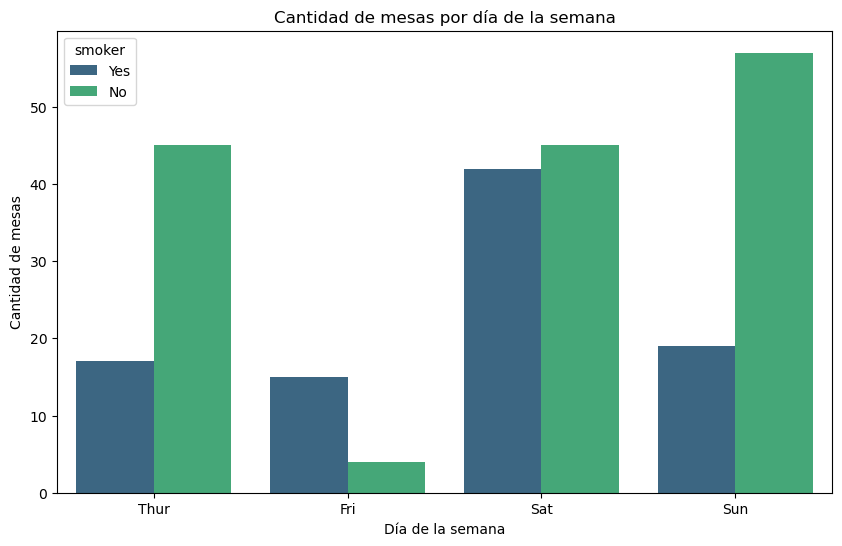

In [50]:
# Gráfico de conteo: días de mayor afluencia diferenciando fumadores
plt.figure(figsize=(10, 6))
sns.countplot(x='day', hue='smoker', data=df_tips, palette='viridis')
plt.title('Cantidad de mesas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de mesas')
plt.show()